In [195]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [196]:
def compute_gradient(x, y, w, b):

    m = len(x) # no. of training examples
    dj_dw = 0 # the gradient of cost j w.r.t. the parameter w
    dj_db = 0 # the gradient of cost j w.r.t. the parameter b
    
    for i in range(m):
        # predicted value
        f_wb_xi = w * x[i] + b # y_hat = f_wb_xi
        
        # calculate partial derivatives and update gradients
        dj_dw += (f_wb_xi - y[i]) * x[i]
        dj_db += f_wb_xi - y[i]

    
    # divide by training examples
    dj_dw = (1 / m) * dj_dw
    dj_db = (1 / m) * dj_db
    
    # result
    return (dj_dw, dj_db)
    
# w = w - a * dj_dw
# b = b - a * dj_db
# a -> Learning rate 

# Scratch Linear Regression model

epoch : How many times entire training dataset reuse(reuse -> repeadtely learning algorithm process)

Intuitively, in one epoch the entire training dataset passes through the learning algorithm(model).

[Training dataset] -> [model] 

# Batch gradient descent
Batch : Each step of gradient descent uses all the training examples.

oR

Each parameter update uses all the training examples  or full gradients.

In [197]:
class LinearRegressionX:
    def __init__(self):
        # Initializing the parameters w and b
        self.w = 0.0 # weight
        self.b = 0.0 # bias
        self.X_mean = None
        self.X_std = None
    
    def fit(self, X, y, lr = 0.01, epochs=1000):
        # X -> univariant feature, y -> actual data, lr -> learning rate
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        
        # calculate mean and standard deviation
        self.X_mean = np.mean(X)
        self.X_std = np.std(X)
        
        # avoid if standard deviation is 0
        if self.X_std == 0:
            raise Exception('Cannot divide by zero!')
        
        # standardized
        x = (X - self.X_mean) / self.X_std
        m = X.shape[0] # no. of training examples
        w, b = [], []
        
        for _ in range(epochs):             
            # prediction
            y_hat = self.w * x + self.b
            
            # calculate error 
            error = (y_hat - y)
            
            # gradients descent
            dw = (1 / m) * np.sum(error * x)
            db = (1 / m) * np.sum(error)
            
            # parameters update
            self.w -= lr * dw
            self.b -= lr * db
            
            # gather vaules of w and b
            w.append(self.w)
            b.append(self.b)
        
        return w, b

    def predict(self, X):
        # avoid none-type std
        if self.X_std is None:
            raise Exception('Standard deviation none type found!')
        
        X = np.asarray(X, dtype=float)
        x = (X - self.X_mean) / self.X_std
        
        # predication
        y_hat = self.w * x + self.b
        return y_hat


In [198]:
# Load data from dataset
house_df = pd.read_csv('melb_data.csv.zip')
# house_df.head()
# house_df.isnull().sum()
house_df.columns
house_df.Landsize

0        202.0
1        156.0
2        134.0
3         94.0
4        120.0
         ...  
13575    652.0
13576    333.0
13577    436.0
13578    866.0
13579    362.0
Name: Landsize, Length: 13580, dtype: float64

In [199]:
# feature names
feature_names = ['Lattitude', 'Longtitude', 'Rooms', 'Landsize']

# DataFrame univariant feature-> X
X = house_df.Landsize

# target values
y = house_df.Price

model = LinearRegressionX()
# # fit dataset
w, b = model.fit(X, y)
w = np.asarray(w)
b = np.asarray(b)

# # predication
y_hat = model.predict(X)

# # cost function(J(w,b))
m = len(X)
# J = (1 / (2 * m)) * np.sum((y_hat - y)**2)
J = (0.5 * m) * np.sum((y_hat - y)**2)

# outputs 
print(f"Predication:\n {y_hat}")
print(f"\nCost function J(w,b) = {J}")
print(f"\nActual data:\n {y}")

Predication:
 [1073496.11955773 1073219.72920604 1073087.5425161  ... 1074902.10525982
 1077485.75419956 1074457.47730275]

Cost function J(w,b) = 3.763137999609209e+19

Actual data:
 0        1480000.0
1        1035000.0
2        1465000.0
3         850000.0
4        1600000.0
           ...    
13575    1245000.0
13576    1031000.0
13577    1170000.0
13578    2500000.0
13579    1285000.0
Name: Price, Length: 13580, dtype: float64


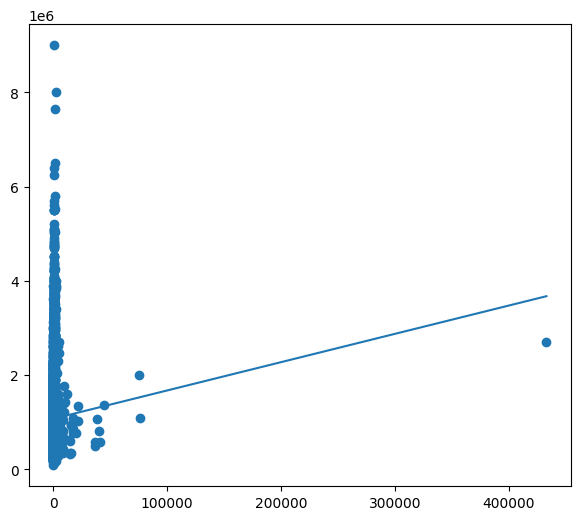

In [200]:
i = np.argsort(X)
X_sort = X[i]
y_sort = y[i]
y_hat_sort = y_hat[i]

fig, ax = plt.subplots(figsize=(7,6))
# Actual data 
ax.scatter(X, y)

# predicated data
ax.plot(X_sort, y_hat_sort)

plt.show()

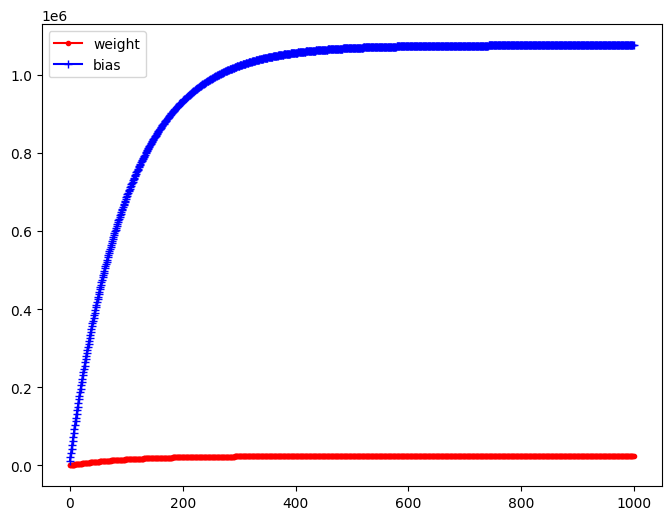

In [227]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(w, color='r', marker='.', label='weight')
ax.plot(b, color='b', marker='+', label='bias')

ax.legend()

plt.show()

In [202]:
from sklearn.linear_model import LinearRegression

# feature names
feature_names = ['Lattitude', 'Longtitude', 'Rooms']

# DataFrame -> X
X = pd.DataFrame(house_df['Landsize'])

# actual data
y = house_df['Price']

model = LinearRegression()
model.fit(X, y)
y_hat_b = model.predict(X)

print(f"Built-in model result\n {y_hat_b}")
print(f"\nOwn model result\n {y_hat}")


Built-in model result
 [1073542.46572513 1073266.0634408  1073133.87104395 ... 1074948.51212799
 1077532.27261189 1074503.86497495]

Own model result
 [1073496.11955773 1073219.72920604 1073087.5425161  ... 1074902.10525982
 1077485.75419956 1074457.47730275]
